<a href="https://colab.research.google.com/github/pratheeth123/ML-LAB/blob/main/Week5/Week5_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 98.25%

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



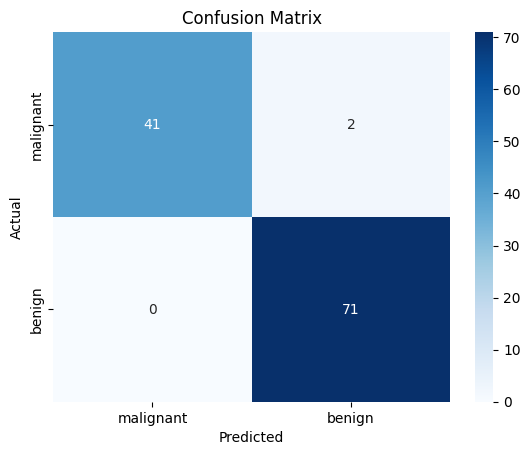

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=data.target_names, yticklabels=data.target_names, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score

# Load dataset
data = fetch_california_housing()
X = data.data[:, [0]]  # use one feature for easy visualization
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVM Regression
model = SVR(kernel='rbf')
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.4431110088237875


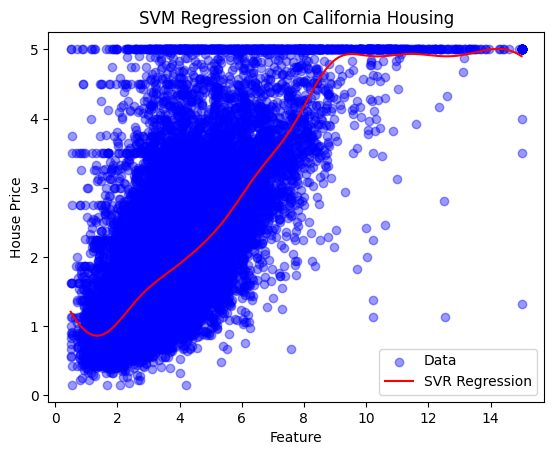

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Create smooth input values
X_grid = np.linspace(X.min(), X.max(), 500).reshape(-1,1)
X_grid_scaled = scaler.transform(X_grid)

# Predict
y_svr = model.predict(X_grid_scaled)

# Plot
plt.scatter(X, y, color='blue', alpha=0.4, label="Data")
plt.plot(X_grid, y_svr, color='red', label="SVR Regression")

plt.title("SVM Regression on California Housing")
plt.xlabel("Feature")
plt.ylabel("House Price")
plt.legend()
plt.show()